<a href="https://colab.research.google.com/github/muditkumar14/capstone-ames-data-intelligence/blob/main/Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# ============================================================
# Part 2 - Supervised Machine Learning
# Load Cleaned Dataset
# ============================================================

import pandas as pd
import numpy as np

# Machine Learning Libraries
from sklearn.model_selection import train_test_split

# ============================================================
# Load Cleaned Dataset
# ============================================================

df = pd.read_csv("cleaned_data.csv")

print("=" * 60)
print("CLEANED DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print("\nFirst 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns.tolist())

# ============================================================
# Define Features and Target Variables
# ============================================================

# Regression Target
y_reg = df["SalePrice"]

# Feature Matrix
X = df.drop(columns=["SalePrice"])

# Classification Target
# Houses above median sale price = 1
# Houses below or equal to median = 0

y_clf = (y_reg > y_reg.median()).astype(int)

print("\n" + "=" * 60)
print("FEATURE MATRIX AND TARGET VARIABLES")
print("=" * 60)

print(f"Feature Matrix Shape : {X.shape}")
print(f"Regression Target Shape : {y_reg.shape}")
print(f"Classification Target Shape : {y_clf.shape}")

# ============================================================
# Check Class Distribution
# ============================================================

print("\nClassification Label Distribution")

print(y_clf.value_counts())

print("\nClass Distribution (%)")

print((y_clf.value_counts(normalize=True) * 100).round(2))

CLEANED DATASET LOADED SUCCESSFULLY

First 5 Rows
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr So

In [19]:
# ============================================================
# Encode Categorical Variables
# ============================================================

print("=" * 60)
print("CATEGORICAL FEATURE ENCODING")
print("=" * 60)

# ------------------------------------------------------------
# Ordinal (Naturally Ordered) Columns
# ------------------------------------------------------------

ordinal_mappings = {

    "Lot Shape": {
        "IR3": 0,
        "IR2": 1,
        "IR1": 2,
        "Reg": 3
    }
}

# Apply Label Encoding using mapping
for col, mapping in ordinal_mappings.items():
    if col in X.columns:
        X[col] = X[col].map(mapping)

print("\nOrdinal Encoding Applied:")
print(list(ordinal_mappings.keys()))

# ------------------------------------------------------------
# Nominal Columns
# ------------------------------------------------------------

nominal_cols = X.select_dtypes(include=["object", "category"]).columns

# Remove already encoded ordinal columns
nominal_cols = [col for col in nominal_cols if col not in ordinal_mappings]

print("\nNominal Columns")
print(nominal_cols)

# ------------------------------------------------------------
# One-Hot Encoding
# ------------------------------------------------------------

X = pd.get_dummies(
    X,
    columns=nominal_cols,
    drop_first=True
)

print("\nOne-Hot Encoding Completed")

print("\nEncoded Feature Matrix Shape")

print(f"Encoded Feature Matrix Shape : {X.shape}")

CATEGORICAL FEATURE ENCODING

Ordinal Encoding Applied:
['Lot Shape']

Nominal Columns
['MS Zoning', 'Street', 'Alley', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature', 'Sale Type', 'Sale Condition']

One-Hot Encoding Completed

Encoded Feature Matrix Shape
Encoded Feature Matrix Shape : (2930, 260)


In [20]:
# ============================================================
# Train-Test Split (Regression & Classification)
# ============================================================

from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

# Split dataset once for both regression and classification
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X,
    y_reg,
    y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

print(f"Training Feature Shape : {X_train.shape}")
print(f"Testing Feature Shape  : {X_test.shape}")

print(f"\nRegression Training Labels : {y_reg_train.shape}")
print(f"Regression Testing Labels  : {y_reg_test.shape}")

print(f"\nClassification Training Labels : {y_clf_train.shape}")
print(f"Classification Testing Labels  : {y_clf_test.shape}")

print("=" * 60)
print("FEATURE SCALING")
print("=" * 60)

print("\nChecking Data Types Before Scaling")
print("\nData Types After Encoding")
print(X.dtypes.value_counts())

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

print("\nStandardScaler fitted on training data only.")

print(f"Scaled Training Shape : {X_train_scaled.shape}")
print(f"Scaled Testing Shape  : {X_test_scaled.shape}")

TRAIN-TEST SPLIT
Training Feature Shape : (2344, 260)
Testing Feature Shape  : (586, 260)

Regression Training Labels : (2344,)
Regression Testing Labels  : (586,)

Classification Training Labels : (2344,)
Classification Testing Labels  : (586,)
FEATURE SCALING

Checking Data Types Before Scaling

Data Types After Encoding
bool       221
int64       28
float64     11
Name: count, dtype: int64

StandardScaler fitted on training data only.
Scaled Training Shape : (2344, 260)
Scaled Testing Shape  : (586, 260)


In [21]:
# ============================================================
# Linear Regression Model
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("=" * 60)
print("LINEAR REGRESSION MODEL")
print("=" * 60)

# ------------------------------------------------------------
# Train the Model
# ------------------------------------------------------------

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_reg_train)

print("Linear Regression model trained successfully.")

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

y_pred_reg = linear_model.predict(X_test_scaled)

print("Prediction completed.")

# ------------------------------------------------------------
# Model Evaluation
# ------------------------------------------------------------

mse = mean_squared_error(y_reg_test, y_pred_reg)
r2 = r2_score(y_reg_test, y_pred_reg)

print("\nModel Performance")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score               : {r2:.4f}")

# ============================================================
# Feature Coefficients
# ============================================================

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

# Create Absolute Coefficient column
coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()

# Sort by absolute coefficient
coefficients = coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

print("\nFeature Coefficients")
print(coefficients)

# ------------------------------------------------------------
# Top 3 Most Important Features
# ------------------------------------------------------------

top3 = coefficients.head(3)

top3_features = top3["Feature"].tolist()

print("\nTop 3 Important Features")
print(top3_features)

print("\nTop 3 Features with Highest Absolute Coefficients")
print(top3[["Feature", "Coefficient"]])

LINEAR REGRESSION MODEL
Linear Regression model trained successfully.
Prediction completed.

Model Performance
Mean Squared Error (MSE): 1863406444.86
R² Score               : 0.6623

Feature Coefficients
                Feature   Coefficient  Absolute Coefficient
116   Roof Matl_CompShg  5.876631e+04          5.876631e+04
120   Roof Matl_Tar&Grv  4.769678e+04          4.769678e+04
121   Roof Matl_WdShake  2.836804e+04          2.836804e+04
43         MS Zoning_RL  2.402280e+04          2.402280e+04
11         BsmtFin SF 1  2.301112e+04          2.301112e+04
..                  ...           ...                   ...
92     Condition 1_RRNn -1.276679e+01          1.276679e+01
117   Roof Matl_Membran  2.484740e-09          2.484740e-09
118     Roof Matl_Metal  1.555236e-09          1.555236e-09
146  Exterior 2nd_Other  8.117240e-10          8.117240e-10
245   Misc Feature_TenC -9.094947e-13          9.094947e-13

[260 rows x 3 columns]

Top 3 Important Features
['Roof Matl_CompShg', 'Ro

In [22]:
# ============================================================
# Ridge Regression Model
# ============================================================

from sklearn.linear_model import Ridge

print("=" * 60)
print("RIDGE REGRESSION MODEL")
print("=" * 60)

# ------------------------------------------------------------
# Train Ridge Regression
# ------------------------------------------------------------

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_reg_train)

print("Ridge Regression model trained successfully.")

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

y_pred_ridge = ridge_model.predict(X_test_scaled)

print("Prediction completed.")

# ------------------------------------------------------------
# Model Evaluation
# ------------------------------------------------------------

ridge_mse = mean_squared_error(y_reg_test, y_pred_ridge)
ridge_r2 = r2_score(y_reg_test, y_pred_ridge)

print("\nModel Performance")
print(f"Mean Squared Error (MSE): {ridge_mse:.2f}")
print(f"R² Score               : {ridge_r2:.4f}")

# ============================================================
# Comparison with Linear Regression
# ============================================================

comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse, ridge_mse],
    "R² Score": [r2, ridge_r2]
})

print("\nRegression Model Comparison")
comparison_df = comparison_df.round(4)

print(comparison_df)

RIDGE REGRESSION MODEL
Ridge Regression model trained successfully.
Prediction completed.

Model Performance
Mean Squared Error (MSE): 1736962721.11
R² Score               : 0.6852

Regression Model Comparison
               Model           MSE  R² Score
0  Linear Regression  1.863406e+09    0.6623
1   Ridge Regression  1.736963e+09    0.6852


In [23]:
# ============================================================
# Logistic Regression Classification Model
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 60)
print("LOGISTIC REGRESSION MODEL")
print("=" * 60)

# ------------------------------------------------------------
# Check Class Distribution
# ------------------------------------------------------------

print("\nTraining Class Distribution")

class_counts = y_clf_train.value_counts()

print(class_counts)

class_percentage = (
    class_counts / len(y_clf_train) * 100
).round(2)

print("\nClass Distribution (%)")

print(class_percentage)

# ------------------------------------------------------------
# Check Imbalance
# ------------------------------------------------------------

if class_percentage.min() < 35:
    print("\nClass imbalance detected.")
    print("Using class_weight='balanced'.")

    logistic_model = LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    )

else:
    print("\nDataset is balanced.")
    print("No imbalance handling required.")

    logistic_model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

# ------------------------------------------------------------
# Train Model
# ------------------------------------------------------------

logistic_model.fit(
    X_train_scaled,
    y_clf_train
)

print("\nLogistic Regression model trained successfully.")

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

y_pred_clf = logistic_model.predict(X_test_scaled)

y_pred_proba = logistic_model.predict_proba(
    X_test_scaled
)[:,1]

print("Prediction completed.")

# ============================================================
# Model Evaluation
# ============================================================

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

cm = confusion_matrix(
    y_clf_test,
    y_pred_clf
)

print("\nConfusion Matrix")

print(cm)

accuracy = accuracy_score(
    y_clf_test,
    y_pred_clf
)

baseline_precision = precision_score(
    y_clf_test,
    y_pred_clf
)

baseline_recall = recall_score(
    y_clf_test,
    y_pred_clf
)

baseline_f1 = f1_score(
    y_clf_test,
    y_pred_clf
)

print(f"\nAccuracy : {accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1 Score : {baseline_f1:.4f}")

print("\nClassification Report")

print(
    classification_report(
        y_clf_test,
        y_pred_clf
    )
)

LOGISTIC REGRESSION MODEL

Training Class Distribution
SalePrice
0    1174
1    1170
Name: count, dtype: int64

Class Distribution (%)
SalePrice
0    50.09
1    49.91
Name: count, dtype: float64

Dataset is balanced.
No imbalance handling required.

Logistic Regression model trained successfully.
Prediction completed.

MODEL PERFORMANCE

Confusion Matrix
[[272  21]
 [ 23 270]]

Accuracy : 0.9249
Precision: 0.9278
Recall   : 0.9215
F1 Score : 0.9247

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       293
           1       0.93      0.92      0.92       293

    accuracy                           0.92       586
   macro avg       0.92      0.92      0.92       586
weighted avg       0.92      0.92      0.92       586



ROC CURVE AND AUC

AUC Score : 0.9654


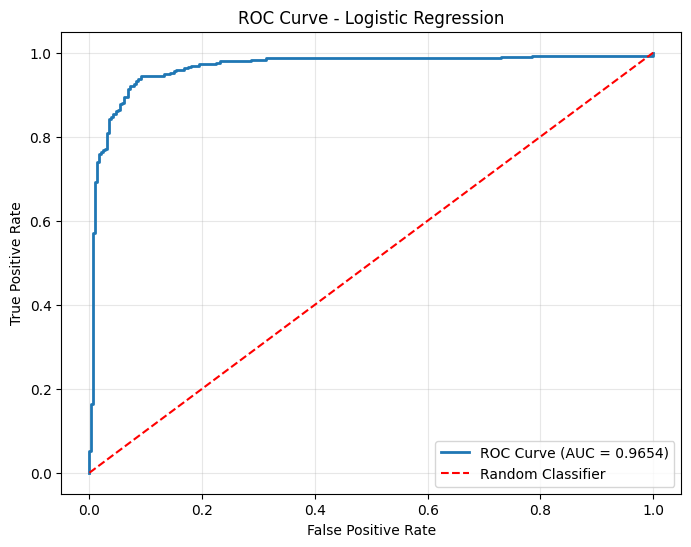

In [24]:
# ============================================================
# ROC Curve and AUC Score
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

print("=" * 60)
print("ROC CURVE AND AUC")
print("=" * 60)

# ------------------------------------------------------------
# Calculate ROC Curve
# ------------------------------------------------------------

fpr, tpr, thresholds = roc_curve(
    y_clf_test,
    y_pred_proba
)

# ------------------------------------------------------------
# Calculate AUC
# ------------------------------------------------------------

auc_score = roc_auc_score(
    y_clf_test,
    y_pred_proba
)

print(f"\nAUC Score : {auc_score:.4f}")

# ------------------------------------------------------------
# Plot ROC Curve
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {auc_score:.4f})",
    linewidth=2
)

# Random Guess Line
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="red",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

In [25]:
# ============================================================
# Decision Threshold Sensitivity Analysis
# ============================================================

from sklearn.metrics import precision_score, recall_score, f1_score

print("=" * 60)
print("DECISION THRESHOLD SENSITIVITY ANALYSIS")
print("=" * 60)

# Thresholds to evaluate
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

results = []

for threshold in thresholds:

    # Convert probabilities into class labels
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    # Calculate metrics
    threshold_precision = precision_score(
        y_clf_test,
        y_pred_threshold
    )

    threshold_recall = recall_score(
        y_clf_test,
        y_pred_threshold
    )

    threshold_f1 = f1_score(
        y_clf_test,
        y_pred_threshold
    )

    results.append({
        "Threshold": threshold,
        "Precision": round(threshold_precision, 4),
        "Recall": round(threshold_recall, 4),
        "F1 Score": round(threshold_f1, 4)
    })

# Convert to DataFrame
threshold_df = pd.DataFrame(results)

print("\nThreshold Performance")
print(threshold_df)

# ============================================================
# Best Threshold
# ============================================================

best_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

print("\nBest Threshold Based on F1 Score")

print(f"Threshold : {best_row['Threshold']}")
print(f"Precision : {best_row['Precision']}")
print(f"Recall    : {best_row['Recall']}")
print(f"F1 Score  : {best_row['F1 Score']}")

DECISION THRESHOLD SENSITIVITY ANALYSIS

Threshold Performance
   Threshold  Precision  Recall  F1 Score
0        0.3     0.8994  0.9454    0.9218
1        0.4     0.9167  0.9386    0.9275
2        0.5     0.9278  0.9215    0.9247
3        0.6     0.9293  0.8976    0.9132
4        0.7     0.9382  0.8805    0.9085

Best Threshold Based on F1 Score
Threshold : 0.4
Precision : 0.9167
Recall    : 0.9386
F1 Score  : 0.9275


In [26]:
# ============================================================
# Logistic Regression Regularization Experiment
# ============================================================


print("=" * 60)
print("LOGISTIC REGRESSION REGULARIZATION EXPERIMENT")
print("=" * 60)

# ------------------------------------------------------------
# Strong Regularization Model (C = 0.01)
# ------------------------------------------------------------

logistic_model_c001 = LogisticRegression(
    C=0.01,
    max_iter=1000,
    random_state=42
)

logistic_model_c001.fit(
    X_train_scaled,
    y_clf_train
)

print("Logistic Regression (C = 0.01) trained successfully.")

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

y_pred_c001 = logistic_model_c001.predict(X_test_scaled)

y_pred_proba_c001 = logistic_model_c001.predict_proba(
    X_test_scaled
)[:, 1]

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

precision_c001 = precision_score(
    y_clf_test,
    y_pred_c001
)

recall_c001 = recall_score(
    y_clf_test,
    y_pred_c001
)

auc_c001 = roc_auc_score(
    y_clf_test,
    y_pred_proba_c001
)

# ============================================================
# Comparison
# ============================================================

comparison_logistic = pd.DataFrame({

    "Model":[
        "Logistic Regression (C=1.0)",
        "Logistic Regression (C=0.01)"
    ],

    "Precision":[
        round(baseline_precision,4),
        round(precision_c001,4)
    ],

    "Recall":[
        round(baseline_recall,4),
        round(recall_c001,4)
    ],

    "AUC":[
        round(auc_score,4),
        round(auc_c001,4)
    ]

})

print("\nModel Comparison")

comparison_logistic = comparison_logistic.round(4)

print(comparison_logistic)

LOGISTIC REGRESSION REGULARIZATION EXPERIMENT
Logistic Regression (C = 0.01) trained successfully.

Model Comparison
                          Model  Precision  Recall     AUC
0   Logistic Regression (C=1.0)     0.9278  0.9215  0.9654
1  Logistic Regression (C=0.01)     0.9252  0.9283  0.9791


In [27]:
# ============================================================
# Bootstrap Confidence Interval for AUC Difference
# ============================================================


print("=" * 60)
print("BOOTSTRAP CONFIDENCE INTERVAL FOR AUC DIFFERENCE")
print("=" * 60)

# Number of bootstrap samples
n_bootstrap = 500

auc_differences = []

# Convert to numpy arrays for indexing
y_test_array = np.array(y_clf_test)

proba_c1 = np.array(y_pred_proba)
proba_c001 = np.array(y_pred_proba_c001)

# ------------------------------------------------------------
# Bootstrap Sampling
# ------------------------------------------------------------

np.random.seed(42)
for i in range(n_bootstrap):

    # Sample indices with replacement
    sample_index = np.random.choice(
        len(y_test_array),
        size=len(y_test_array),
        replace=True
    )

    # Bootstrap samples
    y_sample = y_test_array[sample_index]

    proba1 = proba_c1[sample_index]
    proba2 = proba_c001[sample_index]

    # Skip if bootstrap sample contains only one class
    if len(np.unique(y_sample)) < 2:
        continue

    auc1 = roc_auc_score(y_sample, proba1)
    auc2 = roc_auc_score(y_sample, proba2)

    auc_differences.append(auc1 - auc2)

# ============================================================
# Confidence Interval
# ============================================================

mean_difference = np.mean(auc_differences)

lower_bound = np.percentile(auc_differences, 2.5)

upper_bound = np.percentile(auc_differences, 97.5)

print("\nBootstrap Results")

print(f"Mean AUC Difference : {mean_difference:.4f}")
print(f"95% CI Lower Bound  : {lower_bound:.4f}")
print(f"95% CI Upper Bound  : {upper_bound:.4f}")

# ============================================================
# Interpretation
# ============================================================

print("\nInterpretation")

if lower_bound > 0 or upper_bound < 0:
    print("The 95% confidence interval excludes zero.")
    print("The performance difference between the two models is likely reliable.")
else:
    print("The 95% confidence interval includes zero.")
    print("The observed performance difference may not be statistically reliable.")

BOOTSTRAP CONFIDENCE INTERVAL FOR AUC DIFFERENCE

Bootstrap Results
Mean AUC Difference : -0.0133
95% CI Lower Bound  : -0.0255
95% CI Upper Bound  : -0.0032

Interpretation
The 95% confidence interval excludes zero.
The performance difference between the two models is likely reliable.
